In [1]:
import pandas as pd
import numpy as np
import mysql.connector

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root123",
    database="fraud_growth_db"
)

print("Connected successfully!")

Connected successfully!


In [6]:
query = """
SELECT
    t.amount,
    t.device_risk_score,
    t.geo_risk_score,
    t.merchant_category,
    u.user_segment,
    u.tenure_days,
    t.is_fraud
FROM transactions t
JOIN users u
ON t.user_id = u.user_id
"""

df = pd.read_sql(query, conn)

df.head()

C:\Users\chawl\AppData\Local\Temp\ipykernel_30400\4259624986.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,amount,device_risk_score,geo_risk_score,merchant_category,user_segment,tenure_days,is_fraud
0,31.32570,0.450375,0.452995,electronics,low,715,0
1,7.93702,0.295916,0.178344,food,medium,215,0
2,64.42490,0.215217,0.180407,retail,low,230,0
3,36.39760,0.242987,0.150698,retail,low,489,0
4,13.31530,0.160120,0.225078,retail,high,320,0


In [7]:
print("Dataset shape:", df.shape)

df.describe()

Dataset shape: (800000, 7)


,amount,device_risk_score,geo_risk_score,tenure_days,is_fraud
count,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000
mean,89.986915,0.199999,0.249919,367.985775,0.010959
std,117.481272,0.120541,0.144402,211.166271,0.104109
min,0.482095,0.000073,0.000197,1.000000,0.000000
25%,27.821750,0.107157,0.137725,185.000000,0.000000
50%,54.515000,0.179779,0.228374,372.000000,0.000000
75%,107.275000,0.272198,0.340808,551.000000,0.000000
max,5318.330000,0.867712,0.924436,731.000000,1.000000


In [8]:
df["is_fraud"].value_counts(normalize=True)

is_fraud
0    0.989041
1    0.010959
Name: proportion, dtype: float64

In [10]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

In [11]:
numeric_features = [
    "amount",
    "device_risk_score",
    "geo_risk_score",
    "tenure_days"
]

categorical_features = [
    "merchant_category",
    "user_segment"
]

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [14]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [15]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['amount',
                                                   'device_risk_score',
                                                   'geo_risk_score',
                                                   'tenure_days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['merchant_category',
                                                   'user_segment'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [16]:
y_pred_prob = model.predict_proba(X_test)[:,1]

In [17]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.5846799873908008


In [18]:
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    158247
           1       0.00      0.00      0.00      1753

    accuracy                           0.99    160000
   macro avg       0.49      0.50      0.50    160000
weighted avg       0.98      0.99      0.98    160000



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


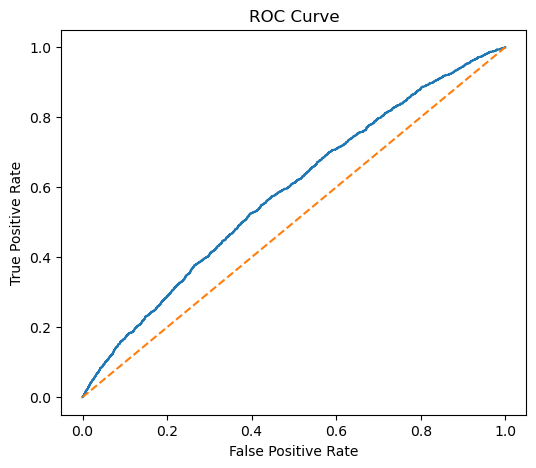

In [19]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [20]:
test_results = X_test.copy()

test_results["fraud_probability"] = y_pred_prob
test_results["is_fraud"] = y_test.values

test_results.head()

,amount,device_risk_score,geo_risk_score,merchant_category,user_segment,tenure_days,fraud_probability,is_fraud
350027,14.2734,0.311404,0.213608,subscription,low,218,0.011228,0
137625,56.2717,0.020073,0.095188,electronics,medium,661,0.006016,0
226776,21.7419,0.030649,0.510779,travel,medium,568,0.010986,0
733144,42.0459,0.243369,0.706026,electronics,low,288,0.021570,0
426180,22.9710,0.162409,0.369223,subscription,high,218,0.011708,0


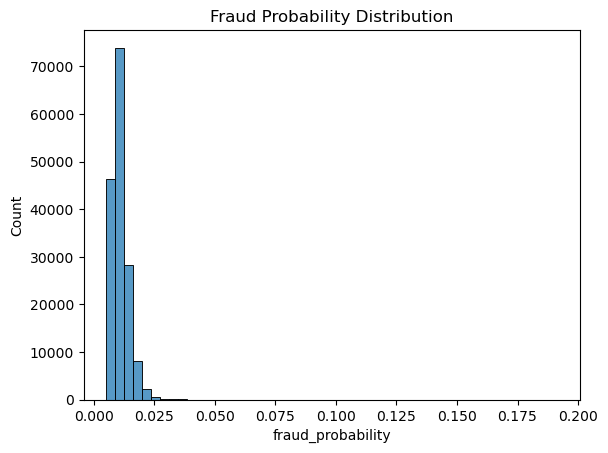

In [21]:
sns.histplot(test_results["fraud_probability"], bins=50)
plt.title("Fraud Probability Distribution")
plt.show()

In [23]:
df_sim = test_results.copy()
df_sim

,amount,device_risk_score,geo_risk_score,merchant_category,user_segment,tenure_days,fraud_probability,is_fraud
350027,14.2734,0.311404,0.213608,subscription,low,218,0.011228,0
137625,56.2717,0.020073,0.095188,electronics,medium,661,0.006016,0
226776,21.7419,0.030649,0.510779,travel,medium,568,0.010986,0
733144,42.0459,0.243369,0.706026,electronics,low,288,0.021570,0
426180,22.9710,0.162409,0.369223,subscription,high,218,0.011708,0
...,...,...,...,...,...,...,...,...
680665,40.9705,0.195219,0.096026,travel,low,133,0.008557,0
629670,364.9640,0.219465,0.116872,travel,medium,198,0.010884,0
62263,33.8613,0.204360,0.302203,travel,low,634,0.010223,0
730487,53.6858,0.112098,0.189758,food,high,165,0.009301,0


In [24]:
#Buisness Assumption 
take_rate = 0.025   # 2.5% payment fee
fraud_loss_multiplier = 1.0   # assume full transaction loss
false_decline_penalty = 0.01  # estimated lost future revenue

In [26]:
#Define Threshold Range
thresholds = np.arange(0.01, 0.5, 0.01)

In [27]:
#Threshold Simulation
results = []

for threshold in thresholds:

    df_sim["decline"] = (df_sim["fraud_probability"] > threshold).astype(int)

    approved = df_sim[df_sim["decline"] == 0]
    declined = df_sim[df_sim["decline"] == 1]

    # revenue from legitimate approved transactions
    revenue = (approved["amount"] * take_rate * (1 - approved["is_fraud"])).sum()

    # fraud loss from approved fraud transactions
    fraud_loss = (approved["amount"] * approved["is_fraud"] * fraud_loss_multiplier).sum()

    # false decline cost (legitimate transactions wrongly declined)
    false_declines = declined[declined["is_fraud"] == 0]
    false_decline_cost = (false_declines["amount"] * false_decline_penalty).sum()

    profit = revenue - fraud_loss - false_decline_cost

    results.append({
        "threshold": threshold,
        "revenue": revenue,
        "fraud_loss": fraud_loss,
        "false_decline_cost": false_decline_cost,
        "profit": profit
    })

results_df = pd.DataFrame(results)

In [28]:
results_df.head()

,threshold,revenue,fraud_loss,false_decline_cost,profit
0,0.01,127676.494390,44513.84955,90871.831829,-7709.186989
1,0.02,334477.067838,160593.77664,8151.602450,165731.688748
2,0.03,350545.825003,175059.05862,1724.099584,173762.666799
3,0.04,352854.647912,175059.05862,800.570420,176995.018872
4,0.05,353675.531462,179588.16862,472.217000,173615.145842


In [29]:
#best Threshold
best_row = results_df.loc[results_df["profit"].idxmax()]

best_row

threshold                  0.040000
revenue               352854.647912
fraud_loss            175059.058620
false_decline_cost       800.570420
profit                176995.018872
Name: 3, dtype: float64

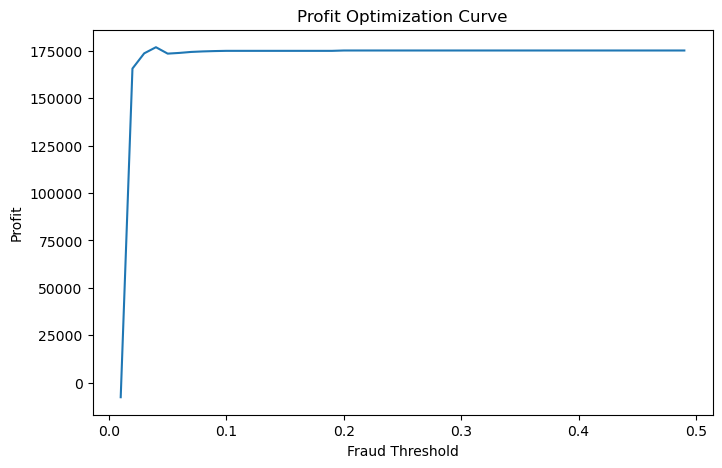

In [31]:
#Plot Profit vs Threshold
plt.figure(figsize=(8,5))

plt.plot(results_df["threshold"], results_df["profit"])
plt.xlabel("Fraud Threshold")
plt.ylabel("Profit")
plt.title("Profit Optimization Curve")

plt.show()

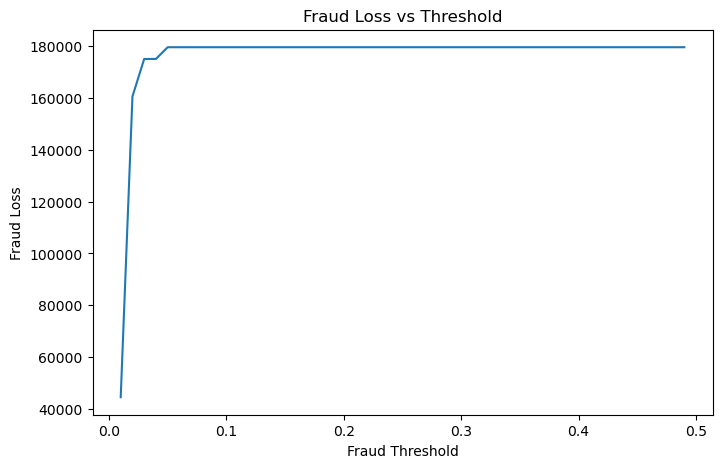

In [32]:
#Plot Fraud Loss vs Threshold
plt.figure(figsize=(8,5))

plt.plot(results_df["threshold"], results_df["fraud_loss"])
plt.xlabel("Fraud Threshold")
plt.ylabel("Fraud Loss")
plt.title("Fraud Loss vs Threshold")

plt.show()


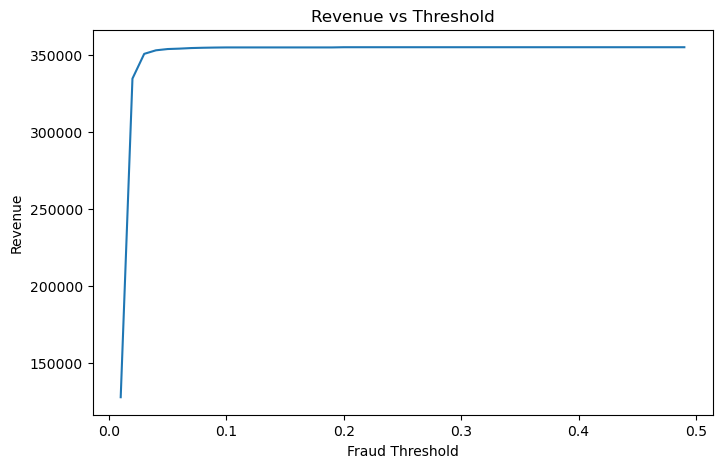

In [33]:
#Plot Revenue vs Threshold
plt.figure(figsize=(8,5))

plt.plot(results_df["threshold"], results_df["revenue"])
plt.xlabel("Fraud Threshold")
plt.ylabel("Revenue")
plt.title("Revenue vs Threshold")

plt.show()